
# 3. Exploración inicial de datos 



In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inspección inicial de datos
ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.sort_values("Fecha").reset_index(drop=True)

df.head()


,Fecha,Calamar,Achi_shift,ElBanco_shift
0,1975-06-17,578.0,536.0,749.0
1,1975-06-18,580.0,552.0,750.0
2,1975-06-19,580.0,571.0,754.0
3,1975-06-20,580.0,580.0,759.0
4,1975-06-21,578.0,571.0,759.0


In [29]:
# Dimensión, tipo de datos, rango temporal

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (18516, 4)

Tipos de datos:
Fecha            datetime64[ns]
Calamar                 float64
Achi_shift              float64
ElBanco_shift           float64
dtype: object


In [30]:
# Rango temporal

print("\nFecha inicial:", df["Fecha"].min()) 
print("Fecha final:", df["Fecha"].max()) 
print("Número de fechas únicas:", df["Fecha"].nunique())


Fecha inicial: 1975-06-17 00:00:00
Fecha final: 2026-02-24 00:00:00
Número de fechas únicas: 18516


In [31]:
# Resumen DataFrame

df.info()
df[["Calamar", "Achi_shift", "ElBanco_shift"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18516 entries, 0 to 18515
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          18516 non-null  datetime64[ns]
 1   Calamar        18366 non-null  float64       
 2   Achi_shift     14949 non-null  float64       
 3   ElBanco_shift  18094 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 578.8 KB


,Calamar,Achi_shift,ElBanco_shift
count,18366.000000,14949.000000,18094.000000
mean,548.556680,461.457972,636.974560
std,168.431197,141.852846,139.651302
min,112.000000,50.000000,241.000000
25%,438.000000,366.000000,537.000000
50%,554.000000,463.000000,639.000000
75%,671.000000,554.000000,742.000000
max,950.000000,829.000000,957.000000


In [32]:
# Datos faltantes

df.isnull().sum()

Fecha               0
Calamar           150
Achi_shift       3567
ElBanco_shift     422
dtype: int64

c:\Users\Victus\anaconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Victus\anaconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Victus\anaconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Victus\anaconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

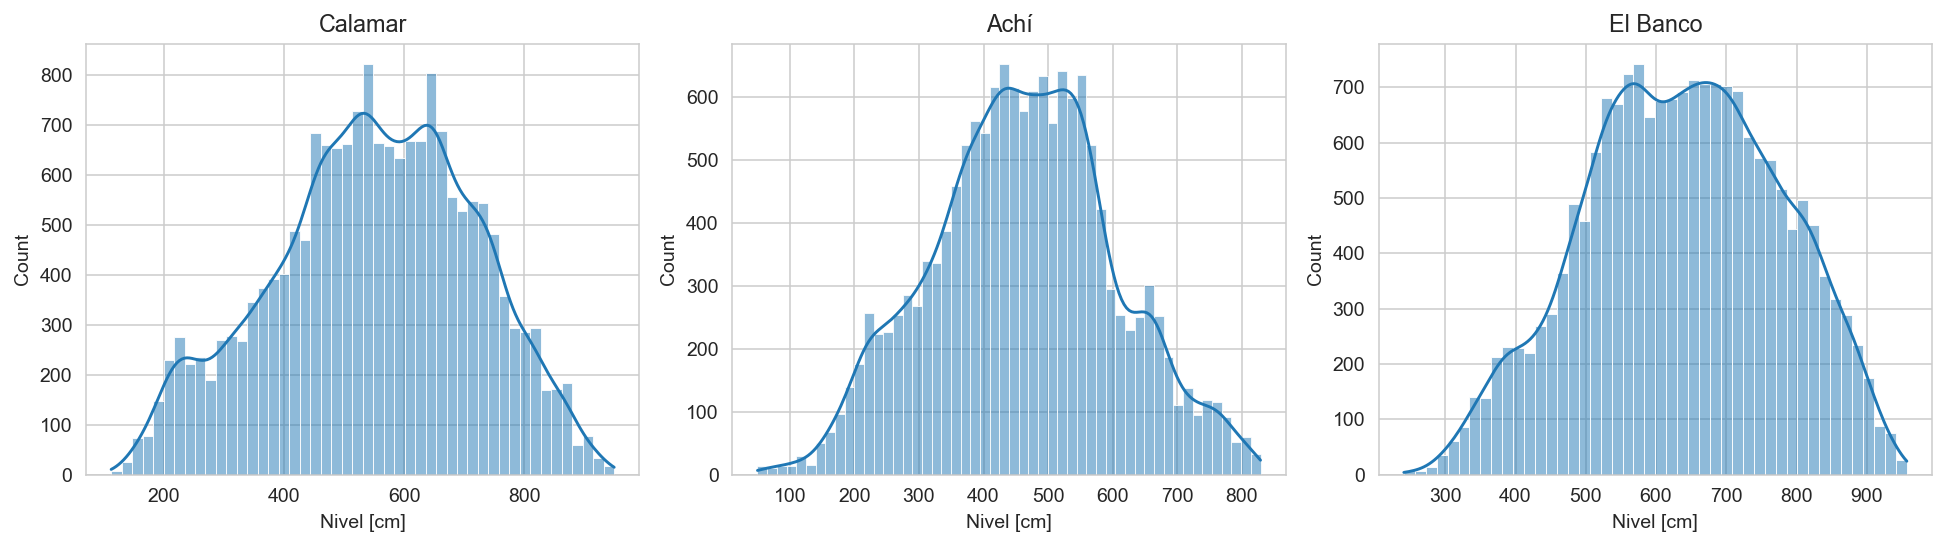

In [35]:
# Histogramas de las series
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=140)

sns.histplot(df["Calamar"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Calamar")

sns.histplot(df["Achi_shift"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Achí")

sns.histplot(df["ElBanco_shift"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("El Banco")

for ax in axes:
    ax.set_xlabel("Nivel [cm]")

plt.tight_layout()
plt.show()

C:\Users\Victus\AppData\Local\Temp\ipykernel_8672\3025215466.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


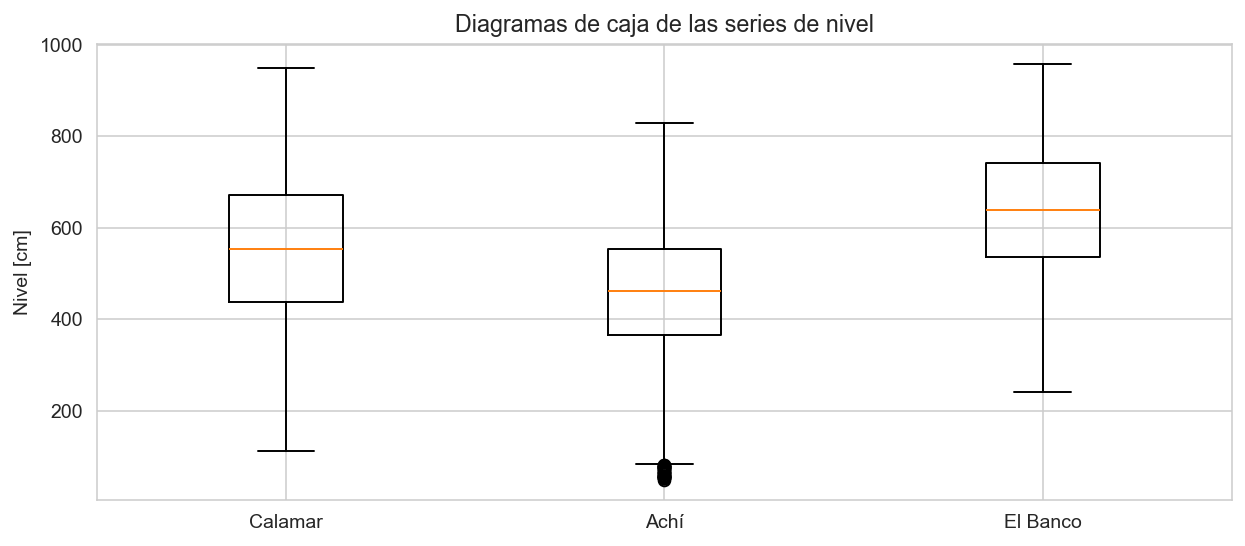

In [36]:
# Box Plots
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4), dpi=140)

plt.boxplot(
    [
        df["Calamar"].dropna(),
        df["Achi_shift"].dropna(),
        df["ElBanco_shift"].dropna()
    ],
    labels=["Calamar", "Achí", "El Banco"],
    patch_artist=False
)

plt.title("Diagramas de caja de las series de nivel")
plt.ylabel("Nivel [cm]")
plt.tight_layout()
plt.show()